# Dimensionality Reduction & Unsupervised Clustering

**Task 04 — PCA, K-Means, DBSCAN and Hierarchical Clustering**

This notebook uses the built-in **Iris dataset** as a reproducible numerical dataset. It standardizes the features, applies PCA, determines the useful number of principal components using explained variance, evaluates K-Means using the Elbow Method and Silhouette Score, and compares K-Means, DBSCAN and Agglomerative (Hierarchical) clustering using 2D/3D projections.

## 1. Objectives

- Standardize high-dimensional numerical features.
- Apply Principal Component Analysis (PCA).
- Plot explained variance and a scree plot.
- Determine a practical number of principal components.
- Find K-Means cluster count using the Elbow Method and Silhouette Score.
- Visualize clusters in 2D and 3D PCA space.
- Apply DBSCAN and Hierarchical/Agglomerative clustering for comparison.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

pd.set_option('display.max_columns', None)
print('Libraries imported successfully.')


Libraries imported successfully.


## 2. Load and inspect the dataset

In [2]:
iris = load_iris(as_frame=True)
df = iris.frame.copy()
df = df.rename(columns={'target': 'target'})

print(f'Dataset shape: {df.shape}')
display(df.head())
display(df.describe())
print('\nMissing values:')
display(df.isna().sum())


Dataset shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000



Missing values:


sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

The clustering algorithms are trained **without the target labels**. The target is retained only as reference metadata and is not used to form clusters.

In [3]:
feature_cols = iris.feature_names
X = df[feature_cols]
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
display(scaled_df.head())


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


## 3. Principal Component Analysis (PCA)

In [4]:
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

pca_summary = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(explained))],
    'Explained Variance Ratio': explained,
    'Cumulative Explained Variance': cumulative
})
display(pca_summary)


,Principal Component,Explained Variance Ratio,Cumulative Explained Variance
0,PC1,0.729624,0.729624
1,PC2,0.228508,0.958132
2,PC3,0.036689,0.994821
3,PC4,0.005179,1.000000


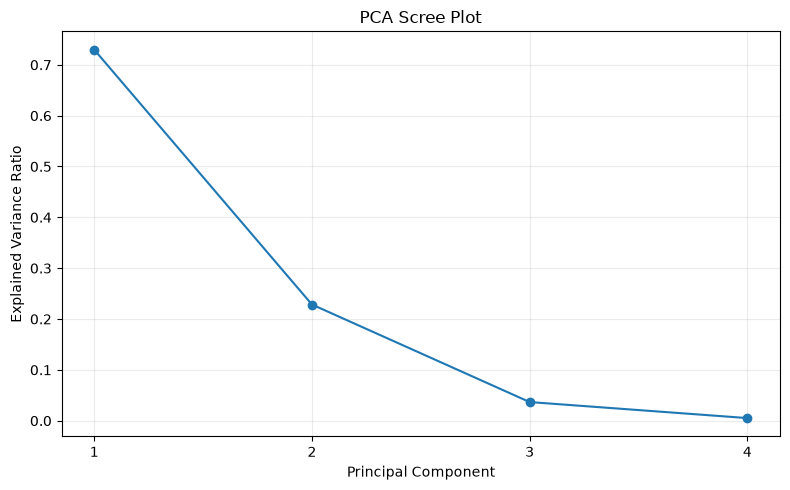

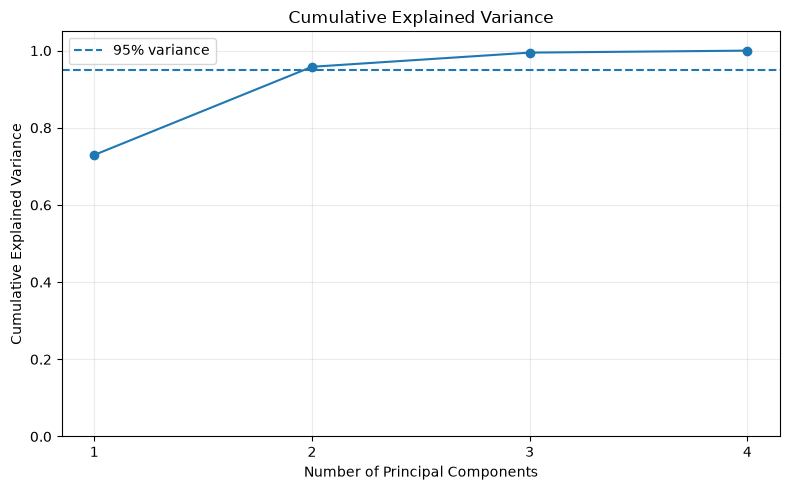

Components required to retain at least 95% variance: 2


In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
components = np.arange(1, len(explained) + 1)
ax.plot(components, explained, marker='o')
ax.set_title('PCA Scree Plot')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_xticks(components)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(components, cumulative, marker='o')
ax.axhline(0.95, linestyle='--', label='95% variance')
ax.set_title('Cumulative Explained Variance')
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_xticks(components)
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

n_components_95 = int(np.argmax(cumulative >= 0.95) + 1)
print(f'Components required to retain at least 95% variance: {n_components_95}')


### PCA projection

In [6]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

print('2D variance retained:', round(pca_2d.explained_variance_ratio_.sum(), 4))
print('3D variance retained:', round(pca_3d.explained_variance_ratio_.sum(), 4))


2D variance retained: 0.9581
3D variance retained: 0.9948


## 4. K-Means: Elbow Method and Silhouette Analysis

In [7]:
k_values = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

results = pd.DataFrame({
    'k': list(k_values),
    'Inertia': inertias,
    'Silhouette Score': silhouette_scores
})
display(results)

best_k_silhouette = int(results.loc[results['Silhouette Score'].idxmax(), 'k'])
print(f'Highest silhouette score occurs at k = {best_k_silhouette}')


,k,Inertia,Silhouette Score
0,2,222.361705,0.581750
1,3,139.820496,0.459948
2,4,114.092547,0.386941
3,5,90.927514,0.345901
4,6,81.544391,0.317079
5,7,72.631144,0.320197
6,8,62.540606,0.338692
7,9,55.119493,0.342360
8,10,47.391035,0.351793


Highest silhouette score occurs at k = 2


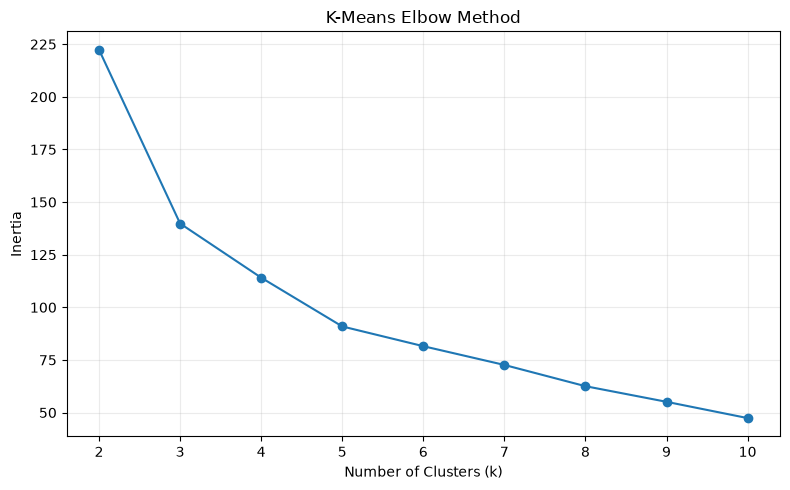

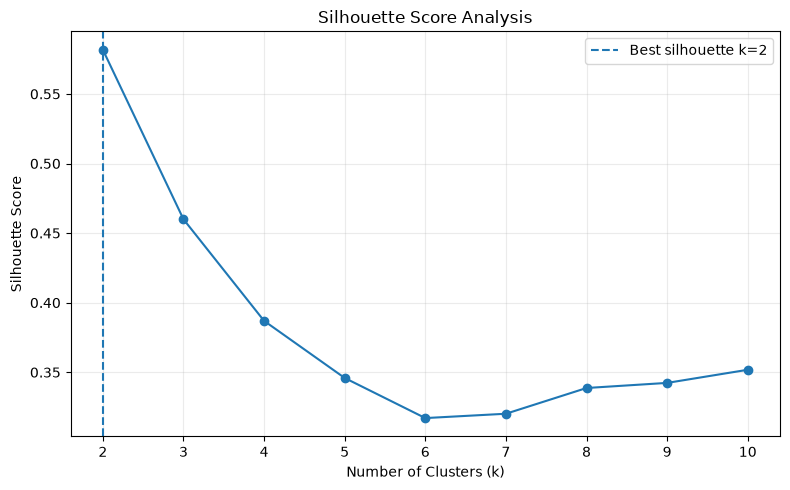

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(results['k'], results['Inertia'], marker='o')
ax.set_title('K-Means Elbow Method')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(results['k'], results['Silhouette Score'], marker='o')
ax.axvline(best_k_silhouette, linestyle='--', label=f'Best silhouette k={best_k_silhouette}')
ax.set_title('Silhouette Score Analysis')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


For the final K-Means model, the silhouette-selected value of `k` is used. The silhouette coefficient ranges from -1 to 1; values closer to 1 indicate better separation between clusters.

In [9]:
kmeans = KMeans(n_clusters=best_k_silhouette, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

final_kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
print(f'Final K-Means clusters: {best_k_silhouette}')
print(f'Final K-Means silhouette score: {final_kmeans_silhouette:.4f}')
print('\nCluster sizes:')
display(pd.Series(kmeans_labels).value_counts().sort_index().rename('Count'))


Final K-Means clusters: 2
Final K-Means silhouette score: 0.5818

Cluster sizes:


0    100
1     50
Name: Count, dtype: int64

## 5. K-Means cluster visualization in 2D PCA space